# 07 — The Mid-Season Exodus: event study

Does a Jul–Aug departure dent a Brasíleirão club's rest-of-season form? Three layered estimators, all logic in `brasileirao.exodus`:
1. **Within-club event study** — treated clubs' pre→post change in Elo-residual points (headline).
2. **Placebo no-effect floor** — the same statistic under random 'treatment' of non-selling clubs; the effect must clear this band.
3. **Difference-in-differences** vs Elo-matched controls, with a pre-window parallel-trends check.

In [1]:
from brasileirao import transfers, ingest, exodus, plotting
import matplotlib.pyplot as plt
import numpy as np

plotting.style()
matches_exp = exodus.elo_expected_points(ingest.load())
dep = transfers.build()
panel = exodus.build_panel(dep, matches_exp)
print(panel['treated'].value_counts())
es = exodus.event_study(panel)
floor = exodus.placebo_floor(panel)
dd = exodus.did(panel)
pt = exodus.parallel_trends(panel)
print('event study Δresid:', round(es['mean_d_resid'], 3), 'CI', [round(x,3) for x in es['ci_resid']])
print('placebo band:', round(floor['lo'], 3), '..', round(floor['hi'], 3), 'mean', round(floor['mean'],3))
print('DiD ATT:', round(dd['att'], 3))
print('parallel trends (treated/control pre-slope):', round(pt['treated_pre_slope'],3), round(pt['control_pre_slope'],3))

treated
False    187
True      53
Name: count, dtype: int64


event study Δresid: -0.079 CI [-0.238, 0.063]
placebo band: -0.088 .. 0.16 mean 0.036
DiD ATT: -0.109
parallel trends (treated/control pre-slope): -0.012 -0.041


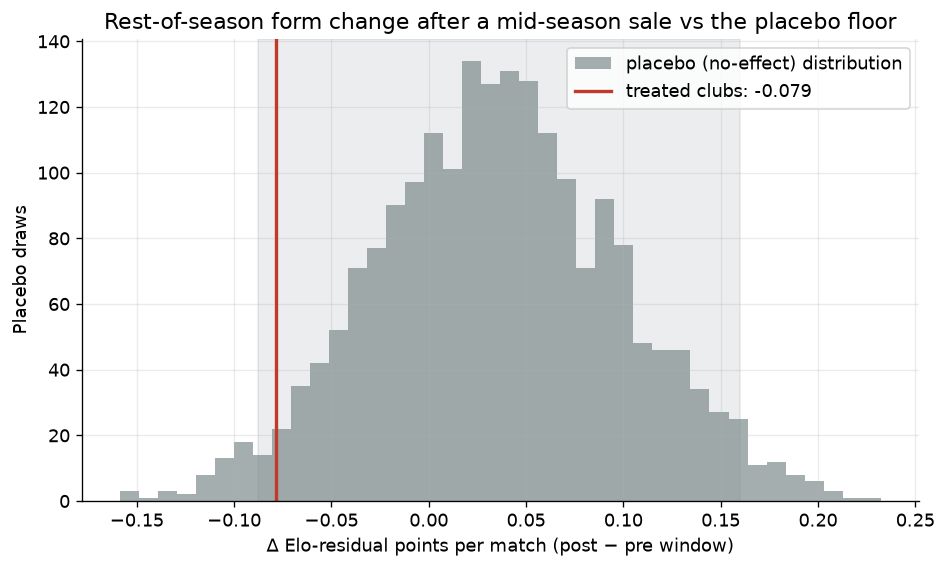

In [2]:
fig, ax = plt.subplots()
ax.hist(floor['dist'], bins=40, color=plotting.COLORS['muted'], alpha=0.7,
        label='placebo (no-effect) distribution')
ax.axvspan(floor['lo'], floor['hi'], color=plotting.COLORS['muted'], alpha=0.15)
ax.axvline(es['mean_d_resid'], color=plotting.COLORS['accent'], lw=2,
           label=f"treated clubs: {es['mean_d_resid']:.3f}")
ax.set(title="Rest-of-season form change after a mid-season sale vs the placebo floor",
       xlabel="Δ Elo-residual points per match (post − pre window)", ylabel="Placebo draws")
ax.legend()
plotting.save(fig, 'exodus_effect_vs_placebo')

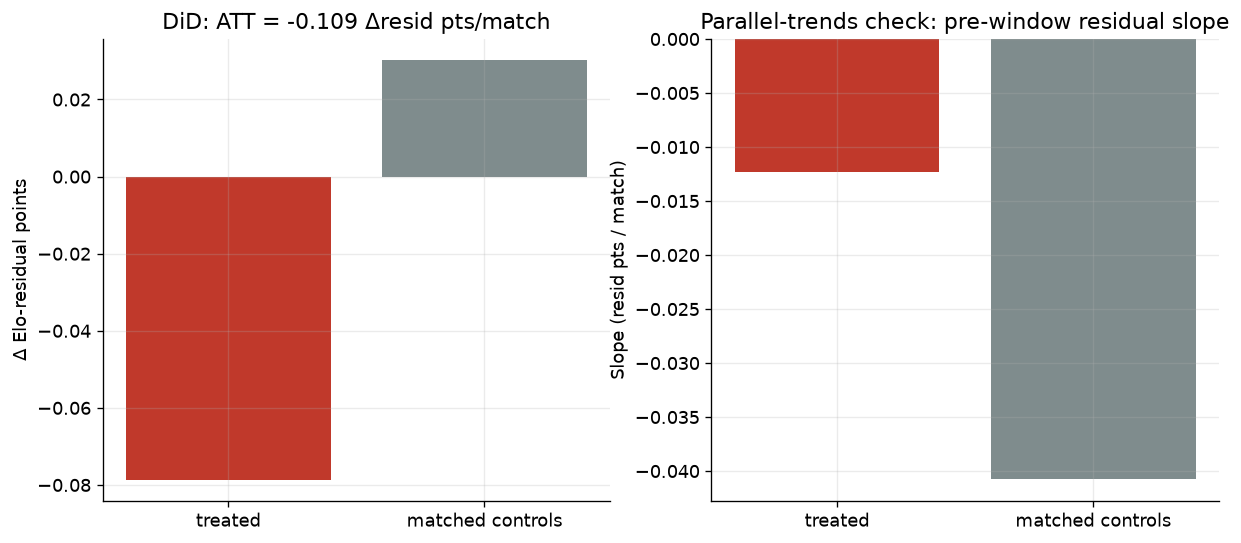

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['treated', 'matched controls'],
            [dd['treated_mean'], dd['control_mean']],
            color=[plotting.COLORS['accent'], plotting.COLORS['muted']])
axes[0].set(title=f"DiD: ATT = {dd['att']:.3f} Δresid pts/match", ylabel='Δ Elo-residual points')
axes[1].bar(['treated', 'matched controls'],
            [pt['treated_pre_slope'], pt['control_pre_slope']],
            color=[plotting.COLORS['accent'], plotting.COLORS['muted']])
axes[1].set(title='Parallel-trends check: pre-window residual slope', ylabel='Slope (resid pts / match)')
plotting.save(fig, 'exodus_did')

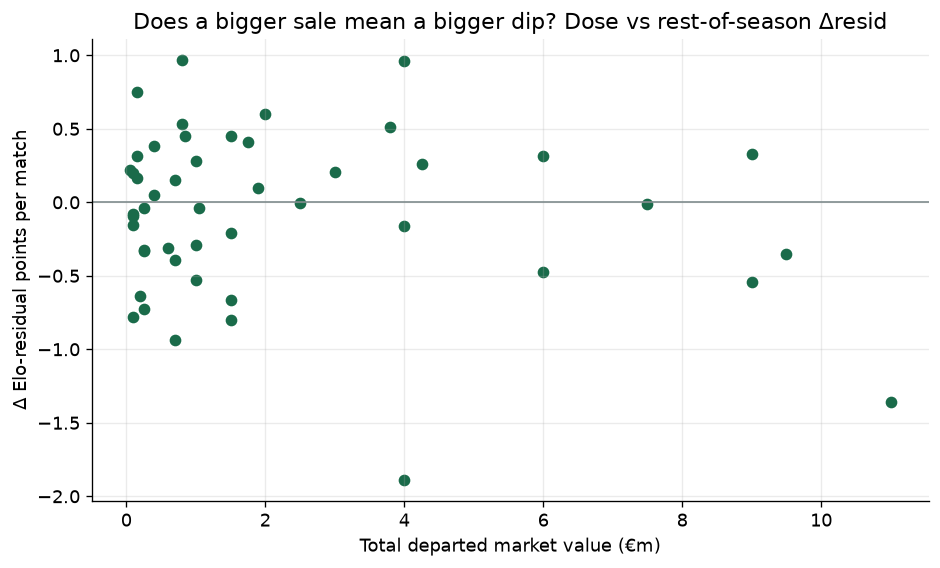

In [4]:
tr = panel[panel['treated'] & (panel['dose_eur'] > 0)]
fig, ax = plt.subplots()
ax.scatter(tr['dose_eur'] / 1e6, tr['d_resid'], color=plotting.COLORS['main'])
ax.axhline(0, color=plotting.COLORS['muted'], lw=1)
ax.set(title="Does a bigger sale mean a bigger dip? Dose vs rest-of-season Δresid",
       xlabel="Total departed market value (€m)", ylabel="Δ Elo-residual points per match")
plotting.save(fig, 'exodus_dose_response')

In [5]:
effect = es['mean_d_resid']
clears_floor = effect < floor['lo'] or effect > floor['hi']
did_survives = abs(dd['att']) > 0 and (dd['att'] < 0) == (effect < 0)
if clears_floor and did_survives:
    verdict = '(a) a real rest-of-season dip that clears the placebo floor and survives DiD'
elif clears_floor and not did_survives:
    verdict = '(b) an apparent dip that vanishes once drift/regression is differenced out'
else:
    verdict = '(c) no detectable effect beyond the placebo floor'
print('VERDICT:', verdict)

VERDICT: (c) no detectable effect beyond the placebo floor
